In [1]:
# you will have to install some packages to the python environment: you can pip install pandas, matplotlib, geopy, pyproj, folium

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from geopy.distance import geodesic
from pyproj import Proj, Transformer
import plotly.express as px
import plotly.graph_objects as go
import random

In [2]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
# import hdbscan
import sklearn.cluster as cluster
from sklearn.preprocessing import StandardScaler
import umap

def process_season_to_df(sampled, sat='s1'):
    dfs = []
    for d in sampled:
        arr = d[sat]
        # Convert the 2D numpy array to a DataFrame
        df = pd.DataFrame(arr)
        # Optionally, add an identifier column if needed, e.g., from another key in the dictionary
        df['uid'] = d['uid']
        dfs.append(df)

    # list of dfs to df
    df = pd.concat(dfs)
    return df

/home/juro4948/miniconda3/envs/ciip/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#########  COSINE SIMILARITY CALCULATION #########
def return_cosine_sim(s1_embeddings, s2_embeddings):
    num_pairs = len(s1_embeddings)
    similarities = []
    for i in range(num_pairs):
        for j in range(i, num_pairs):
            s1 = torch.tensor(s1_embeddings[i])
            s2 = torch.tensor(s2_embeddings[j])
            cos = torch.nn.CosineSimilarity(dim=1)
            cos_sim = cos(s1, s2)
            # convert to numbers
            cos_sim = abs(cos_sim.item())
            similarities.append((i, j, cos_sim))


    return similarities


######### GEOGRAPHICAL DISTANCE CALCULATION #########
def return_distance_calculation(coordinates, vh_crs, vv_crs):
    wgs84 = Proj('epsg:4326')       # WG
    wgs84_transformer = Transformer.from_crs("EPSG:4326", "EPSG:4326", always_xy=True)

    # convert to same crs
    adjusted_coordinates = []
    for coord, vhcrs, vvcrs in zip(coordinates, vh_crs, vv_crs):
        if vhcrs != vvcrs:
            raise ValueError('Different CRS for VH and VV')
        original_proj = Proj(vhcrs)
        transformer = Transformer.from_crs(original_proj.srs, "EPSG:4326", always_xy=True)
        lon, lat = transformer.transform(coord[0], coord[1])
        adjusted_coordinates.append((lat, lon))

    coordinates = adjusted_coordinates
    # calculate distances
    distances = []
    for i in range(len(coordinates)):
        for j in range(i, len(coordinates)):
            coord1 = coordinates[i]
            coord2 = coordinates[j]
            distance = geodesic(coord1, coord2).kilometers
            distances.append((i, j, distance))

    return distances


In [4]:
# dataset class
class Dataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.root = root
        self.samples = sorted(os.listdir(root))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        data = torch.load(os.path.join(self.root, sample)) 
        # convert tensor to np
        data['s1'] = data['s1'].numpy()
        data['s2'] = data['s2'].numpy()

        return data


# this dataset 
class SeasonsDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.root = root
        self.samples = sorted(os.listdir(root))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        location_idx = sample.split('_')[0]
        seasons = [f'{location_idx}_season{season}.pt' for season in [0]] #, 1, 2, 3]]
        data = {}
        for s in seasons:
            path = os.path.join(self.root, s)
            if not os.path.exists(path):
                print(f'{path} does not exist')
                return None
            data[s] = torch.load(path)
            # convert tensor to np
            data[s]['s1'] = data[s]['s1'].numpy()
            data[s]['s2'] = data[s]['s2'].numpy()

        return data


In [5]:
# sampler 
class Sampler():
    def __init__(self, dataset):
        self.dataset = dataset
        self.length = len(dataset)
        print(f"Dataset length: {self.length}")

    def sample(self, num_samples):
        samples = []
        sampled_indices = set()
        while len(samples) < num_samples:
            idx = np.random.randint(0, self.length)
            if idx not in sampled_indices:
                sampled_indices.add(idx)
                samples.append(self.dataset[idx])           
        
        return samples
    
#

class IndicesSampler():
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.length = len(dataset)
        self.indices = indices
        print(f"Dataset length: {self.length}")

    def sample(self):
        samples = []
        for idx in self.indices:
            samples.append(self.dataset[idx])
        
        return samples

In [6]:
from geopy.distance import geodesic
from pyproj import Proj, Transformer

def return_distance_calculation(coordinates, vh_crs, vv_crs):
    wgs84 = Proj('epsg:4326')  # WGS84

    # Check if all CRS are the same and convert coordinates to WGS84
    adjusted_coordinates = []
    for coord, vhcrs, vvcrs in zip(coordinates, vh_crs, vv_crs):
        if vhcrs != vvcrs:
            raise ValueError('Different CRS for VH and VV')
        original_proj = Proj(vhcrs)
        transformer = Transformer.from_crs(original_proj.srs, wgs84.srs, always_xy=True)
        lon, lat = transformer.transform(coord[0], coord[1])
        # print(f"Original coord: {coord}, Transformed coord: {(lat, lon)}")  # Debug print
        adjusted_coordinates.append((lat, lon))

    # Calculate distances between all pairs of coordinates
    distances = []
    for i in range(len(adjusted_coordinates)):
        for j in range(i, len(adjusted_coordinates)):
            coord1 = adjusted_coordinates[i]
            coord2 = adjusted_coordinates[j]
            distance = geodesic(coord1, coord2).kilometers
            distances.append((i, j, distance))

    return distances

# plot coordinates on a map
def plot_coordinates(coordinates, vh_crs, vv_crs):
    import folium

    # Create a map centered at the first coordinate

    map = folium.Map(location=coordinates[0], zoom_start=5)

    # Add a marker for each coordinate
    for coord, vhcrs, vvcrs in zip(coordinates, vh_crs, vv_crs):
        folium.Marker(coord).add_to(map)

    return map

In [7]:
def extract_sample_info(sampled):
    #  extract info
    [sample['metadata']['system:footprint']['type'] for sample in sampled]
    coordinates = [sample['metadata']['system:footprint']['coordinates'][0] for sample in sampled]
    coordinates = [(sample[1], sample[0]) for sample in coordinates]

    vh_crs = [sample['metadata']['system:bands']['VH']['crs'] for sample in sampled]
    vv_crs = [sample['metadata']['system:bands']['VV']['crs'] for sample in sampled]
    s1_embeddings = [sample['s1'] for sample in sampled]
    s2_embeddings = [sample['s2'] for sample in sampled]

    return coordinates, vh_crs, vv_crs, s1_embeddings, s2_embeddings

def get_cosine_similarity(s1_embeddings, s2_embeddings, col1, col2):
    # calculate cosine similarities between every pair of samples
    if col1 == 's1' and col2 == 's2':
        cosine_similarities = return_cosine_sim(s1_embeddings, s2_embeddings)
    elif col1 == 's1' and col2 == 's1':
        cosine_similarities = return_cosine_sim(s1_embeddings, s1_embeddings)
    elif col1 == 's2' and col2 == 's2':
        cosine_similarities = return_cosine_sim(s2_embeddings, s2_embeddings)

    return cosine_similarities




In [8]:
def select_embeddings(method, s1_transformed, s2_transformed, indices):
    return s1_transformed[indices], s2_transformed[indices]


def plot_selected_embeddings(method, selected_df_type1, selected_df_type2, num_locations, title, fig=None, legend=None):
    # If fig is None, create a new figure
    if fig is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        ax = fig.gca()

    colors = plt.cm.get_cmap('tab20', num_locations)
    
    for i in range(num_locations):
        if True:
            print('Plotting model 1 (make sure to input random init vs model 2 (moco init)')
            i = 0
            # map handles to model names
            mapping = {
                's1': 'Random-Init',
                's2': 'MoCo-Init'}
        ax.scatter(selected_df_type1[i, 0], selected_df_type1[i, 1], color=colors(i), label=f's1' if i == 0 else "", alpha=0.7)
        ax.scatter(selected_df_type2[i, 0], selected_df_type2[i, 1], color=colors(i), marker='x', label=f's2' if i == 0 else "", alpha=0.7)
        ax.plot([selected_df_type1[i, 0], selected_df_type2[i, 0]], 
                [selected_df_type1[i, 1], selected_df_type2[i, 1]], 
                color=colors(i), linewidth=0.5, alpha=0.5)
    
    ax.set_xlabel('Embedding Dimension 1')
    ax.set_ylabel('Embedding Dimension 2')
    ax.set_title(title)
    # Only show legend once
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())
    if legend:
        ax.legend(legend)

    # Set equal aspect ratio and shared axis limits
    all_x = np.concatenate([selected_df_type1[:, 0], selected_df_type2[:, 0]])
    all_y = np.concatenate([selected_df_type1[:, 1], selected_df_type2[:, 1]])
    min_val = min(all_x.min(), all_y.min())
    max_val = max(all_x.max(), all_y.max())
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal', adjustable='box')

    return fig

In [9]:
def reduce_dimensionality(method, s1_df, s2_df, title, save=False):
    """Applies PCA or UMAP to reduce dimensionality and plots the results."""
    combined = pd.concat([s1_df.drop(columns=['uid']), s2_df.drop(columns=['uid'])])
    
    if method == 'PCA':
        pca = PCA(n_components=2)
        pca.fit(combined)
        s1_transformed = pca.transform(s1_df.drop(columns=['uid']))
        s2_transformed = pca.transform(s2_df.drop(columns=['uid']))
        plot_2d_scatter(s1_transformed, s2_transformed, 'PCA', title, save)
        return s1_transformed, s2_transformed
    
    elif method == 'PCA-3D':
        pca = PCA(n_components=3)
        pca.fit(combined)
        s1_transformed = pca.transform(s1_df.drop(columns=['uid']))
        s2_transformed = pca.transform(s2_df.drop(columns=['uid']))
        plot_3d_scatter(s1_transformed, s2_transformed, 'PCA-3D', title, save)
        return s1_transformed, s2_transformed
    
    elif method == 'UMAP':
        reducer = umap.UMAP(n_components=2)
        reducer.fit(combined)
        s1_transformed = reducer.transform(s1_df.drop(columns=['uid']))
        s2_transformed = reducer.transform(s2_df.drop(columns=['uid']))
        plot_2d_scatter(s1_transformed, s2_transformed, 'UMAP', title, save)
        return s1_transformed, s2_transformed
    else:
        raise ValueError("Invalid method. Choose from ['PCA', 'PCA-3D', 'UMAP']")

def plot_2d_scatter(s1, s2, method, title, save=False):
    """Plots a 2D scatterplot for dimensionality reduction results."""
    plt.figure(figsize=(5, 5))
    plt.scatter(s1[:, 0], s1[:, 1], s=7, label='Random-Init') # 's1'
    plt.scatter(s2[:, 0], s2[:, 1], s=7, c='r', label='MoCo-Init') # 's2'
    plt.title(title)
    plt.legend()
    if save:
        plt.savefig(f'output/{method}_embeddings.png')
    plt.show()

def plot_3d_scatter(s1, s2, method, num_pairs, save=False):
    """Plots a 3D scatterplot for PCA-3D results."""
    fig = go.Figure(data=[
        go.Scatter3d(x=s1[:, 0], y=s1[:, 1], z=s1[:, 2], mode='markers', marker=dict(size=3), name='s1'),
        go.Scatter3d(x=s2[:, 0], y=s2[:, 1], z=s2[:, 2], mode='markers', marker=dict(size=3, color='red'), name='s2')
    ])
    fig.update_layout(title=title, autosize=False, width=500, height=500)
    if save:
        fig.write_image(f'output/{method}_embeddings.png')
    fig.show()

In [10]:
import torch
import torch.nn.functional as F

def cosine_similarity_matrix(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """
    Computes the cosine similarity matrix between two sets of vectors.

    Args:
        X (torch.Tensor): Tensor of shape (N, D)
        Y (torch.Tensor): Tensor of shape (M, D)

    Returns:
        torch.Tensor: Cosine similarity matrix of shape (N, M)
                      where entry (i, j) is the cosine similarity between X[i] and Y[j]
    """
    # Normalize rows to unit vectors
    X_norm = X / X.norm(dim=1, keepdim=True).clamp(min=1e-8)
    Y_norm = Y / Y.norm(dim=1, keepdim=True).clamp(min=1e-8)

    # Compute cosine similarity as dot product of normalized vectors
    sim_matrix = X_norm @ Y_norm.T  # shape: (N, M)

    return sim_matrix

def unique_cosine_similarities(X: torch.Tensor, Y: torch.Tensor = None) -> torch.Tensor:
    """
    Computes cosine similarity between all unique pairs of embeddings.
    
    If Y is None, computes the upper triangle (without diagonal) of cosine similarity matrix of X vs X.
    If Y is provided and X.shape[0] == Y.shape[0], returns pairwise cosine similarity: X[i] vs Y[i].
    
    Args:
        X (torch.Tensor): Tensor of shape (N, D) where N is the number of samples and D is the embedding dimension.
        Y (torch.Tensor, optional): Tensor of shape (N, D) or (M, D)
        
    Returns:
        torch.Tensor: 1D tensor of cosine similarities for each unique pair.
    """
    if Y is None:
        sim_matrix = cosine_similarity_matrix(X, X)
        # Extract upper triangle without the diagonal
        N = sim_matrix.size(0)
        iu = torch.triu_indices(N, N, offset=1)
        unique_sims = sim_matrix[iu[0], iu[1]]
        return unique_sims
    else:
        assert X.shape == Y.shape, "If Y is provided, X and Y must have the same shape to compute pairwise similarities"
        sim_matrix = cosine_similarity_matrix(X, Y)
        N = sim_matrix.shape[0]
        iu = np.triu_indices(N, k=1)
        upper_triangle_sims = sim_matrix[iu]
        return upper_triangle_sims

def paired_cosine_similarity(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """
    Computes cosine similarity between two sets of embeddings, assuming they are paired.

    Args:
        X (torch.Tensor): Tensor of shape (N, D)
        Y (torch.Tensor): Tensor of shape (N, D)

    Returns:
        torch.Tensor: 1D tensor with cosine similarities for each pair
    """
    assert X.shape == Y.shape, "X and Y must have the same shape to compute paired cosine similarities"
    
    cos_sim = F.cosine_similarity(X, Y, dim=1)
    return cos_sim


def centroid_cosine_similarity(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """
    Computes cosine similarity between the centroids (mean vectors) of two embedding sets.

    Args:
        X (torch.Tensor): Tensor of shape (N, D)
        Y (torch.Tensor): Tensor of shape (M, D)

    Returns:
        torch.Tensor: Scalar tensor with cosine similarity between centroids
    """
    centroid_X = X.mean(dim=0)
    centroid_Y = Y.mean(dim=0)
    
    similarity = F.cosine_similarity(centroid_X.unsqueeze(0), centroid_Y.unsqueeze(0), dim=1)
    return similarity.item()

# Initialization - Cone Effect experiments

In [11]:
import torch
import torch.nn.functional as F

Dataset length: 2000


/tmp/ipykernel_2740979/3525208666.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(self.root, sample))


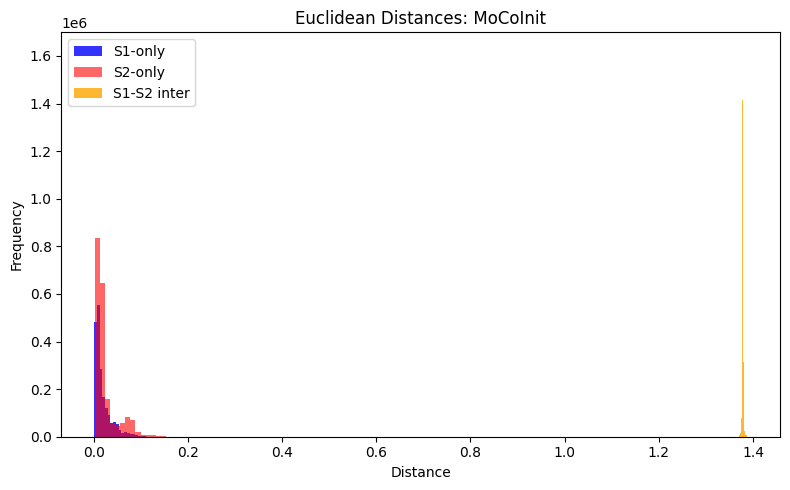

(1999000,)


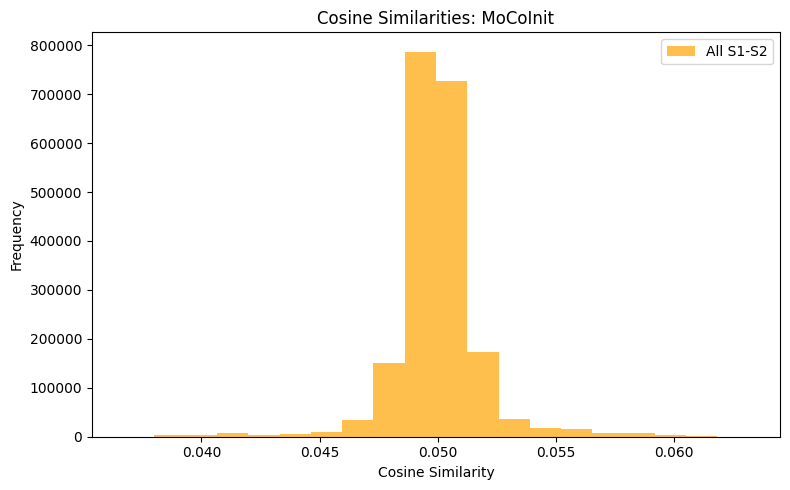

Dataset length: 2000


/tmp/ipykernel_2740979/3525208666.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(self.root, sample))


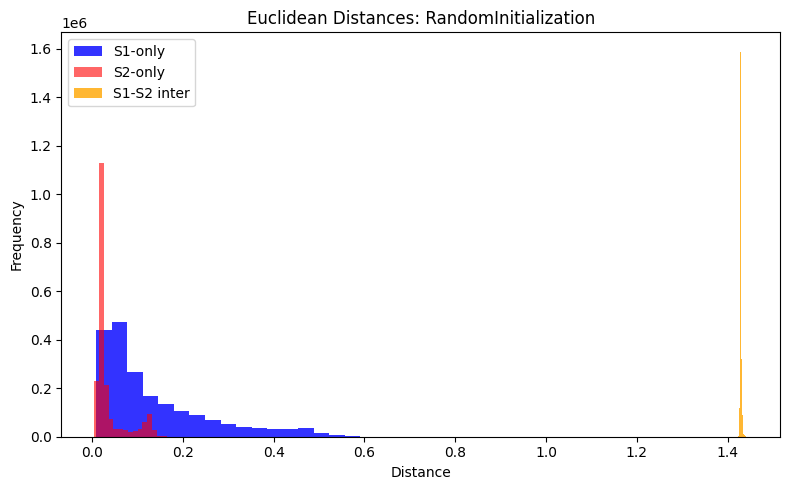

(1999000,)


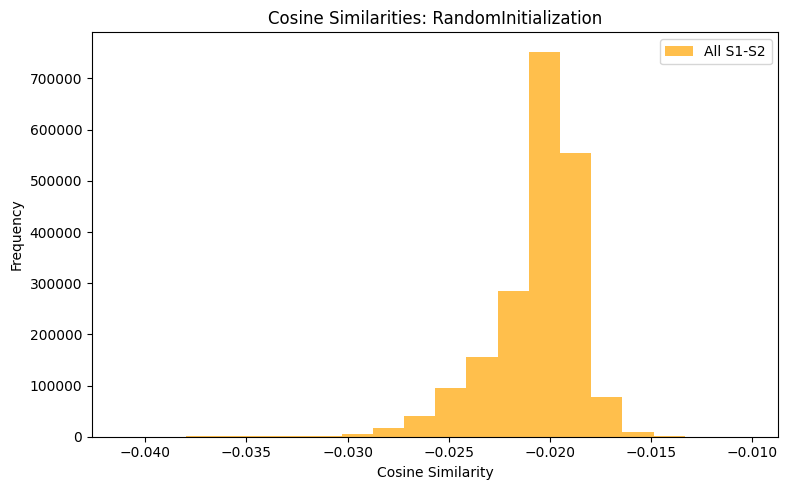

In [14]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

np.random.seed(42)
indices = list(range(2000))
plot_indices = indices

n_bootstrap = 2000
sample_size = 2000
bootstrap_indices = None

model_epochs = ['X']
model_names = ['MoCoInit', 'RandomInitialization']
num_pairs = 2000
num_locations = 2000

for model_name in model_names:
    embeddings_root = f'/local/ms-data/SSL4EO/extracted_embeddings/{model_name}'             

    d = Dataset(embeddings_root)
    sampler = Sampler(d)
    sampled = sampler.sample(num_samples=num_pairs)

    s1_df = process_season_to_df(sampled, sat='s1').drop(columns=['uid'], errors='ignore').reset_index(drop=True)
    s2_df = process_season_to_df(sampled, sat='s2').drop(columns=['uid'], errors='ignore').reset_index(drop=True)


    ### Euclidean Distances
    dist_s1 = euclidean_distances(s1_df, s1_df)
    dist_s2 = euclidean_distances(s2_df, s2_df)
    dist_cross = euclidean_distances(s1_df, s2_df)

    intra_s1 = dist_s1[np.triu_indices_from(dist_s1, k=1)]
    intra_s2 = dist_s2[np.triu_indices_from(dist_s2, k=1)]
    inter_s1s2 = dist_cross.flatten()

    plt.figure(figsize=(8, 5))
    plt.hist(intra_s1, bins=20, alpha=0.8, label='S1-only', color='blue')
    plt.hist(intra_s2, bins=20, alpha=0.6, label='S2-only', color='red')
    plt.hist(inter_s1s2, bins=20, alpha=0.8, label='S1-S2 inter', color='orange')
    plt.title(f'Euclidean Distances: {model_name}')
    plt.xlabel('Distance')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()


    # ### Cosine Similarity
    # Convert DataFrames to tensors
    s1_tensor = torch.tensor(s1_df.values, dtype=torch.float32)
    s2_tensor = torch.tensor(s2_df.values, dtype=torch.float32)

    # 1. Cosine similarity between all s1 samples (upper triangle, excluding diagonal) using the functions defined above
    cos_s1 = unique_cosine_similarities(s1_tensor).numpy()
    

    # 2. Cosine similarity between all s2 samples (upper triangle, excluding diagonal)
    cos_s2 = unique_cosine_similarities(s2_tensor).numpy()


    # 4. Cosine similarity between all s1 and s2 unique pairs (upper triangle, excluding diagonal)
    cos_cross = unique_cosine_similarities(s1_tensor, s2_tensor).numpy()
    print(cos_cross.shape)


    plt.figure(figsize=(8, 5))
    # plt.hist(cos_s1, bins=20, alpha=0.9, label='S1-only', color='blue')
    # plt.hist(cos_s2, bins=20, alpha=0.6, label='S2-only', color='red')
    plt.hist(cos_cross, bins=20, alpha=0.7, label='All S1-S2', color='orange')
    plt.title(f'Cosine Similarities: {model_name}')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

    


Dataset length: 2000


/tmp/ipykernel_2740979/3525208666.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(self.root, sample))


Dataset length: 2000
L2 Norm between centroids of S1 and S2 for MoCoInit: 1.3780606985092163
L2 Norm between centroids of S1 and S2 for RandomInitialization: 1.422696828842163
Cosine Similarity between centroids of S1 and S2 for MoCoInit: 0.05003289878368378
Cosine Similarity between centroids of S1 and S2 for RandomInitialization: -0.020840205252170563


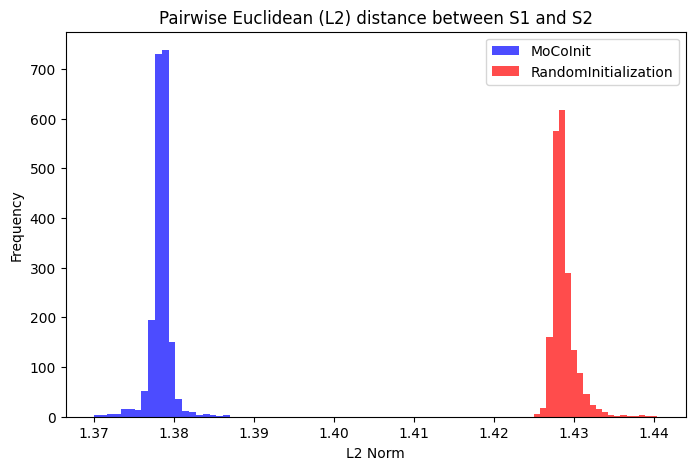

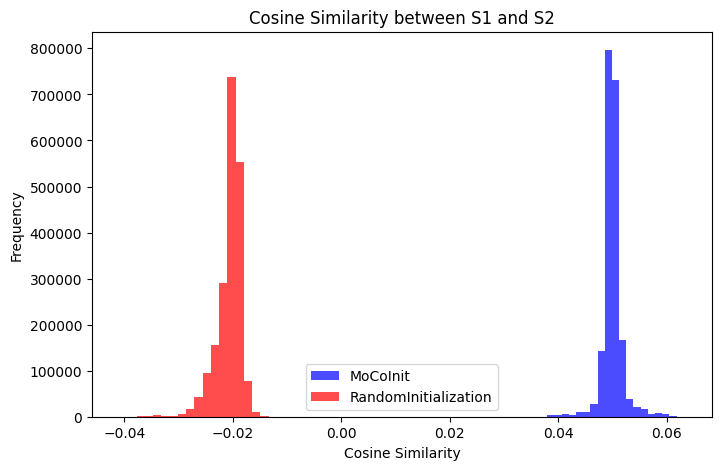

In [15]:
# L2 Norm between S1 and S2

embeddings_root = f'/local/ms-data/SSL4EO/extracted_embeddings/{model_names[0]}' 
embeddings_root2 = f'/local/ms-data/SSL4EO/extracted_embeddings/{model_names[1]}'              

d = Dataset(embeddings_root)
sampler = Sampler(d)
sampled = sampler.sample(num_samples=num_pairs)

d2 = Dataset(embeddings_root2)
sampler2 = Sampler(d2)
sampled2 = sampler2.sample(num_samples=num_pairs)


s1 = process_season_to_df(sampled, sat='s1').drop(columns=['uid'], errors='ignore').reset_index(drop=True)
s2 = process_season_to_df(sampled, sat='s2').drop(columns=['uid'], errors='ignore').reset_index(drop=True)

s1_model2 = process_season_to_df(sampled2, sat='s1').drop(columns=['uid'], errors='ignore').reset_index(drop=True)
s2_model2 = process_season_to_df(sampled2, sat='s2').drop(columns=['uid'], errors='ignore').reset_index(drop=True)

# Calculate L2 norm between s1 and s2 for both models
l2_norm_s1_s2 = np.linalg.norm(s1.values - s2.values, axis=1)
l2_norm_s1_s2_model2 = np.linalg.norm(s1_model2.values - s2_model2.values, axis=1)
# Plot L2 norm distributions
plt.figure(figsize=(8, 5))
plt.hist(l2_norm_s1_s2, bins=20, alpha=0.7, label=f'{model_names[0]}', color='blue')
plt.hist(l2_norm_s1_s2_model2, bins=20, alpha=0.7, label=f'{model_names[1]}', color='red')
plt.title('Pairwise Euclidean (L2) distance between S1 and S2')
plt.xlabel('L2 Norm')
plt.ylabel('Frequency')
plt.legend()


# calculate the distance between centroids of s1 and s2 for both models
s1_centroid = s1.mean(axis=0)
s2_centroid = s2.mean(axis=0)
s1_centroid_model2 = s1_model2.mean(axis=0)
s2_centroid_model2 = s2_model2.mean(axis=0)
l2_norm_centroids = np.linalg.norm(s1_centroid - s2_centroid)
l2_norm_centroids_model2 = np.linalg.norm(s1_centroid_model2 - s2_centroid_model2)
print(f'L2 Norm between centroids of S1 and S2 for {model_names[0]}: {l2_norm_centroids}')
print(f'L2 Norm between centroids of S1 and S2 for {model_names[1]}: {l2_norm_centroids_model2}')


# print cosine similarity between s1 and s2 centroids for both models
# cos_sim_centroids = np.dot(s1_centroid, s2_centroid) / (np.linalg.norm(s1_centroid) * np.linalg.norm(s2_centroid))
# cos_sim_centroids_model2 = np.dot(s1_centroid_model2, s2_centroid_model2) / (np.linalg.norm(s1_centroid_model2) * np.linalg.norm(s2_centroid_model2))
cos_sim_centroids = centroid_cosine_similarity(torch.tensor(s1_centroid).unsqueeze(0), torch.tensor(s2_centroid).unsqueeze(0))
cos_sim_centroids_model2 = centroid_cosine_similarity(torch.tensor(s1_centroid_model2).unsqueeze(0), torch.tensor(s2_centroid_model2).unsqueeze(0))
print(f'Cosine Similarity between centroids of S1 and S2 for {model_names[0]}: {cos_sim_centroids}')
print(f'Cosine Similarity between centroids of S1 and S2 for {model_names[1]}: {cos_sim_centroids_model2}')


# plot cosine similarity across s1 and s2 for both models on same plot
plt.figure(figsize=(8, 5))
# compute all cosine similarity between s1 and s2
cross_s1_s2 = unique_cosine_similarities(torch.tensor(s1.values), torch.tensor(s2.values))
plt.hist(cross_s1_s2, bins=20, alpha=0.7, label=f'{model_names[0]}', color='blue')

cross_s1_s2_model2 = unique_cosine_similarities(torch.tensor(s1_model2.values), torch.tensor(s2_model2.values))
plt.hist(cross_s1_s2_model2, bins=20, alpha=0.7, label=f'{model_names[1]}', color='red')
plt.title('Cosine Similarity between S1 and S2')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()

# # now only plot paired cosine similarity between s1 and s2 for both models
# paired_cos_s1_s2 = np.sum(s1_norm * s2_norm, axis=1)
# paired_cos_s1_s2_model2 = np.sum(s1_norm_model2 * s2_norm_model2, axis=1)
# plt.figure(figsize=(8, 5))
# plt.hist(paired_cos_s1_s2, bins=20, alpha=0.7, label=f'{model_names[0]}', color='blue')
# plt.hist(paired_cos_s1_s2_model2, bins=20, alpha=0.7, label=f'{model_names[1]}', color='red')
# plt.title('Paired Cosine Similarity between S1 and S2')
# plt.xlabel('Cosine Similarity') 
# plt.ylabel('Frequency')
# plt.legend()





# Shift the gap

In [ ]:

def compute_optimal_orthogonal_mapping(X: torch.Tensor, Y: torch.Tensor) -> torch.Tensor:
    """
    Compute the orthogonal matrix W that best aligns Y to X (i.e., X ≈ YW).
    Args:
        X: [N, D] tensor of image embeddings
        Y: [N, D] tensor of text embeddings
    Returns:
        W: [D, D] orthogonal matrix
    """

    # Ensure inputs are float tensors and on same device
    X = X.to(dtype=torch.float32)
    Y = Y.to(dtype=torch.float32)

    X = X.T
    Y = Y.T

    # Optional: normalize to unit norm
    X = X / X.norm(dim=0, keepdim=True).clamp(min=1e-8)
    Y = Y / Y.norm(dim=0, keepdim=True).clamp(min=1e-8)

    # Compute cross-covariance matrix
    A = Y @ X.T  # shape: [dim, dim]

    # SVD decomposition
    U, _, Vt = torch.linalg.svd(A)

    # Compute the orthogonal matrix R
    R = U @ Vt

    # Optional: ensure det(R) == 1 to prevent reflection
    if torch.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = U @ Vt

    return R




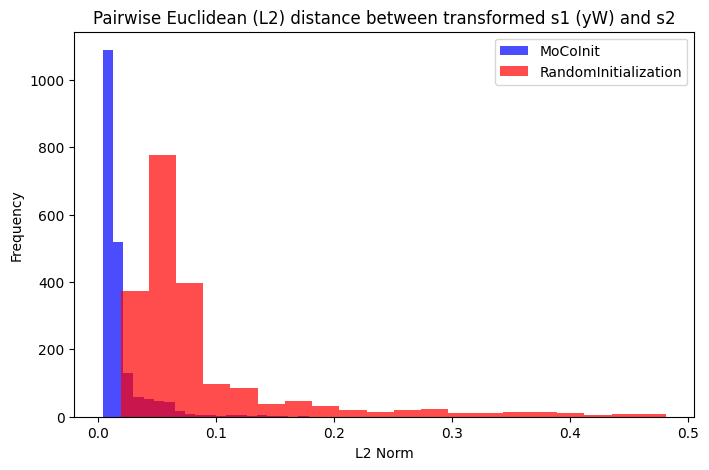

L2 Norm between centroids of yW and x for MoCoInit: 0.00012409065675456077
L2 Norm between centroids of yW and x for RandomInitialization: 0.007455757353454828
Cosine Similarity between centroids of yW and x for MoCoInit: 1.0
Cosine Similarity between centroids of yW and x for RandomInitialization: 0.9999999403953552


/tmp/ipykernel_2740979/2819832736.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cos_yW_x = unique_cosine_similarities(torch.tensor(Y_aligned), torch.tensor(x))
/tmp/ipykernel_2740979/2819832736.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cos_yW_x_model2 = unique_cosine_similarities(torch.tensor(Y_aligned_model2), torch.tensor(x_model2))


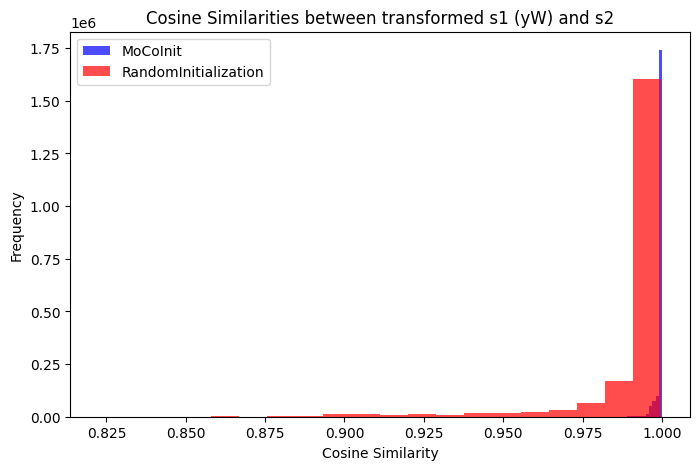

In [17]:
x=torch.tensor(s2.values, dtype=torch.float32)
y=torch.tensor(s1.values, dtype=torch.float32)

W = compute_optimal_orthogonal_mapping(x, y)
Y_aligned = y @ W  # Apply the orthogonal transformation


x_model2=torch.tensor(s2_model2.values, dtype=torch.float32)
y_model2=torch.tensor(s1_model2.values, dtype=torch.float32)
W_model2 = compute_optimal_orthogonal_mapping(x_model2, y_model2)
Y_aligned_model2 = y_model2 @ W_model2  # Apply the orthogonal transformation

# Calculate L2 norm between aligned y and x for both models
l2_norm_yW_x = np.linalg.norm(Y_aligned.numpy() - x.numpy(), axis=1)
l2_norm_yW_x_model2 = np.linalg.norm(Y_aligned_model2.numpy() - x_model2.numpy(), axis=1)

# Plot L2 norm distributions
plt.figure(figsize=(8, 5))
plt.hist(l2_norm_yW_x, bins=20, alpha=0.7, label=f'{model_names[0]}', color='blue')
plt.hist(l2_norm_yW_x_model2, bins=20, alpha=0.7, label=f'{model_names[1]}', color='red')
plt.title('Pairwise Euclidean (L2) distance between transformed s1 (yW) and s2')
plt.xlabel('L2 Norm')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Calculate the distance between centroids of aligned y and x for both models
yW_centroid = Y_aligned.mean(dim=0).numpy()
x_centroid = x.mean(dim=0).numpy()
yW_centroid_model2 = Y_aligned_model2.mean(dim=0).numpy()
x_centroid_model2 = x_model2.mean(dim=0).numpy()

l2_norm_centroids = np.linalg.norm(yW_centroid - x_centroid)
l2_norm_centroids_model2 = np.linalg.norm(yW_centroid_model2 - x_centroid_model2)
print(f'L2 Norm between centroids of yW and x for {model_names[0]}: {l2_norm_centroids}')
print(f'L2 Norm between centroids of yW and x for {model_names[1]}: {l2_norm_centroids_model2}')


# print cosine similarity between yW and x centroids for both models
cos_sim_centroids = np.dot(yW_centroid, x_centroid) / (np.linalg.norm(yW_centroid) * np.linalg.norm(x_centroid))
cos_sim_centroids_model2 = np.dot(yW_centroid_model2, x_centroid_model2) / (np.linalg.norm(yW_centroid_model2) * np.linalg.norm(x_centroid_model2))
print(f'Cosine Similarity between centroids of yW and x for {model_names[0]}: {cos_sim_centroids}')
print(f'Cosine Similarity between centroids of yW and x for {model_names[1]}: {cos_sim_centroids_model2}')


# plot histogram of cosine similarities between all yW and x for both models
cos_yW_x = unique_cosine_similarities(torch.tensor(Y_aligned), torch.tensor(x))
cos_yW_x_model2 = unique_cosine_similarities(torch.tensor(Y_aligned_model2), torch.tensor(x_model2))
plt.figure(figsize=(8, 5))
plt.hist(cos_yW_x, bins=20, alpha=0.7, label=f'{model_names[0]}', color='blue')
plt.hist(cos_yW_x_model2, bins=20, alpha=0.7, label=f'{model_names[1]}', color='red')
plt.title('Cosine Similarities between transformed s1 (yW) and s2')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.show()




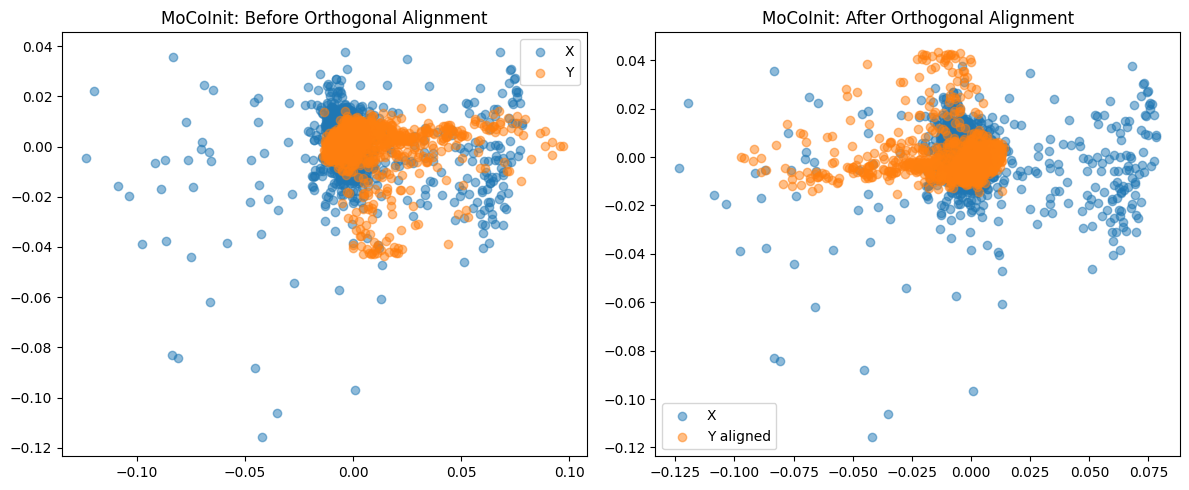

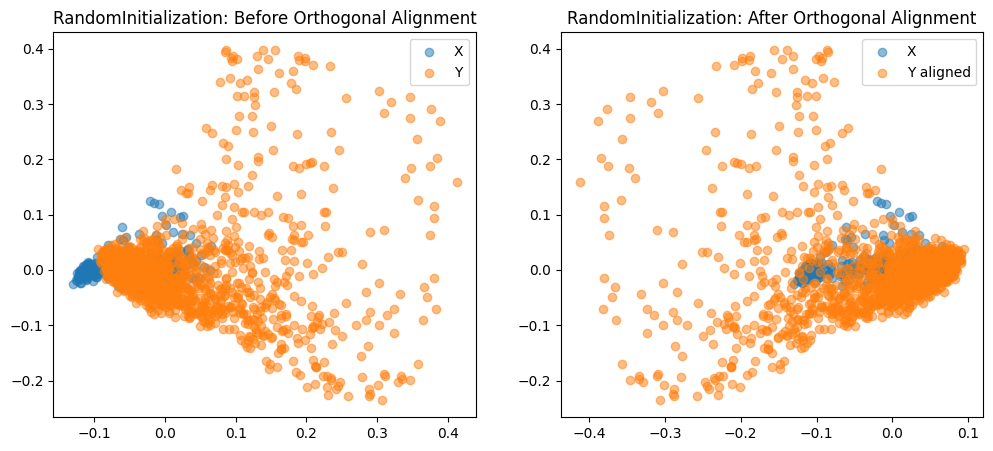

In [22]:
# Assume X and Y are your two modalities as torch tensors
# W is your orthogonal matrix, Y_aligned = Y @ W

# Reduce to 2D for visualization
def to_2d(arr):
    pca = PCA(n_components=2)
    return pca.fit_transform(arr)

X_np = x#.numpy()
Y_np = y#.numpy()
Y_aligned_np = Y_aligned#.numpy()

X_2d = to_2d(X_np)
Y_2d = to_2d(Y_np)
Y_aligned_2d = to_2d(Y_aligned_np)

plt.figure(figsize=(12, 5))

# Before alignment
plt.subplot(1, 2, 1)
plt.scatter(X_2d[:, 0], X_2d[:, 1], label='X', alpha=0.5)
plt.scatter(Y_2d[:, 0], Y_2d[:, 1], label='Y', alpha=0.5)
plt.title(f'{model_names[0]}: Before Orthogonal Alignment')
plt.legend()

# After alignment
plt.subplot(1, 2, 2)
plt.scatter(X_2d[:, 0], X_2d[:, 1], label='X', alpha=0.5)
plt.scatter(Y_aligned_2d[:, 0], Y_aligned_2d[:, 1], label='Y aligned', alpha=0.5)
plt.title(f'{model_names[0]}: After Orthogonal Alignment')
plt.legend()

plt.tight_layout()
plt.show()

# same for random init
X_np_model2 = x_model2#.numpy()
Y_np_model2 = y_model2#.numpy()     
Y_aligned_np_model2 = Y_aligned_model2#.numpy()
X_2d_model2 = to_2d(X_np_model2)
Y_2d_model2 = to_2d(Y_np_model2)
Y_aligned_2d_model2 = to_2d(Y_aligned_np_model2)
plt.figure(figsize=(12, 5))
# Before alignment
plt.subplot(1, 2, 1)    
plt.scatter(X_2d_model2[:, 0], X_2d_model2[:, 1], label='X', alpha=0.5)
plt.scatter(Y_2d_model2[:, 0], Y_2d_model2[:, 1], label='Y', alpha=0.5)
plt.title(f'{model_names[1]}: Before Orthogonal Alignment')
plt.legend()
# After alignment
plt.subplot(1, 2, 2)    
plt.scatter(X_2d_model2[:, 0], X_2d_model2[:, 1], label='X', alpha=0.5)
plt.scatter(Y_aligned_2d_model2[:, 0], Y_aligned_2d_model2[:, 1], label='Y aligned', alpha=0.5)
plt.title(f'{model_names[1]}: After Orthogonal Alignment')
plt.legend()

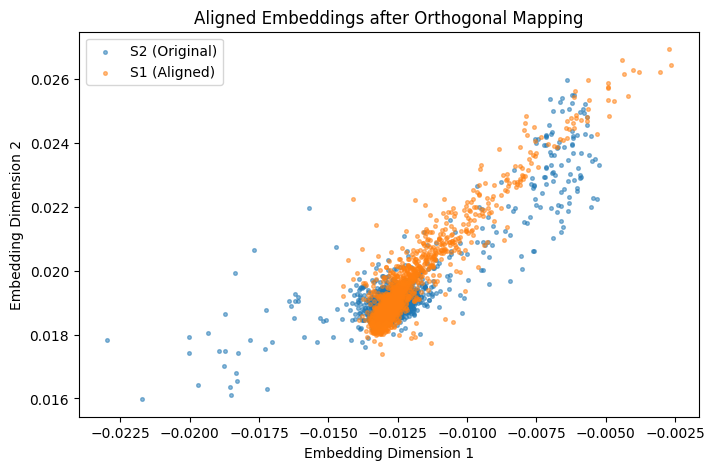

In [19]:
# # plot the aligned embeddings
plt.figure(figsize=(8, 5))
plt.scatter(x[:, 0], x[:, 1], s=7, label='S2 (Original)', alpha=0.5)
plt.scatter(Y_aligned[:, 0], Y_aligned[:, 1], s=7, label='S1 (Aligned)', alpha=0.5)
plt.title('Aligned Embeddings after Orthogonal Mapping')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.legend()

Plot distance between centroids over the training process

In [ ]:
# TODO: lineplot of distance vs epoch for each model

In [ ]:
## For initialization experiments  
np.random.seed(42) 
# indices = np.random.choice(range(10000), size=num_pairs, replace=False)
# plot_indices = random.sample(range(num_pairs), num_locations)

# indices
indices = [i for i in range(2000)]
plot_indices = indices

n_bootstrap = 2000
sample_size = 2000
bootstrap_indices = None


model_epochs = ['X'] #['5', '30', '50', '100']
model_names = ['MoCoInit', 'RandomInitialization']#['Z_2025_03_18', 'Z_2025_03_23', '2025_03_31-MoCoInit-bs256']
num_pairs = 2000
num_locations = 2000



for model_name in model_names[0:1]:
    for model_epoch in model_epochs[0:1]:
        ## For trained models
        # embeddings_root = f'/local/ms-data/SSL4EO/extracted_embeddings/{model_name}/{model_epoch}/val'
        
        ## For initialization experiments  
        embeddings_root = f'/local/ms-data/SSL4EO/extracted_embeddings/{model_name}' 
        embeddings_root2 = f'/local/ms-data/SSL4EO/extracted_embeddings/{model_names[1]}'              

        d = Dataset(embeddings_root)
        sampler = Sampler(d)
        sampled = sampler.sample(num_samples=num_pairs)

        d1 = Dataset(embeddings_root2)
        sampler2 = Sampler(d1)
        sampled2 = sampler2.sample(num_samples=num_pairs)

        # # sampler = IndicesSampler(SeasonsDataset(embeddings_root), indices)
        # season_sampled = sampler.sample(num_pairs)
        # sampled = []
        # for location in season_sampled:
        #     for k, d in location.items():
        #         sampled.append(d)


        uids = [sample['uid'] for sample in sampled]
        s1_df = process_season_to_df(sampled, sat='s1')
        s2_df = process_season_to_df(sampled, sat='s2')

        uids2 = [sample['uid'] for sample in sampled2]
        s1_df2 = process_season_to_df(sampled2, sat='s1')
        s2_df2 = process_season_to_df(sampled2, sat='s2')
      
        # ### PLOT S1 vs S2 embeddings
        # method = 'PCA'
        # title=f'{method}_{model_names}_Epoch{model_epoch}_n={num_pairs}'
        # s1_transformed, s2_transformed = reduce_dimensionality(method, s1_df, s2_df,  title=f'{title}')
        # selected_df_type1, selected_df_type2 = select_embeddings(method, s1_transformed, s2_transformed, plot_indices)
        # f = plot_selected_embeddings(method, selected_df_type1, selected_df_type2, num_locations, title=f'{title},  o=s1, x=s2')
        # # add another f 

        # method = 'UMAP'
        # s1_transformed, s2_transformed = reduce_dimensionality(method, s1_df, s2_df, title=f'{title}')
        # selected_df_type1, selected_df_type2 = select_embeddings(method, s1_transformed, s2_transformed, plot_indices)
        # plot_selected_embeddings(method, selected_df_type1, selected_df_type2, num_locations, title=f'{title},  o=s1, x=s2', fig=f)


        # # ### PLOT Model1 vs Model2 embeddings
        # method = 'PCA'

        
        # title=f'{method}_{model_names}_S1_n={num_pairs}'
        # s1_transformed, s2_transformed = reduce_dimensionality(method, s1_df, s1_df2,  title=f'{title}')
        # selected_df_type1, selected_df_type2 = select_embeddings(method, s1_transformed, s2_transformed, plot_indices)

        # title=f'{method}_{model_names}_S2_n={num_pairs}'
        # s1_transformed_2, s2_transformed_2 = reduce_dimensionality(method, s2_df, s2_df2,  title=f'{title}')
        # selected_df_type1_2, selected_df_type2_2 = select_embeddings(method, s1_transformed_2, s2_transformed_2, plot_indices)

        # legend = [f'{model_names[0]}_s1', f'{model_names[0]}_s2', f'{model_names[1]}_s1', f'{model_names[1]}_s2']

        # title=f'{method}_{model_names}_Epoch{model_epoch}_n={num_pairs}'
        # f = plot_selected_embeddings(method, selected_df_type1, selected_df_type1_2, num_locations, title=f'{title},  s1 embeddings')
        # plot_selected_embeddings(method, selected_df_type2, selected_df_type2_2, num_locations, title=f'{title},  s2 embeddings', fig=f, legend=legend)


        # method = 'UMAP'

        
        # title=f'{method}_{model_names}_S1_n={num_pairs}'
        # s1_transformed, s2_transformed = reduce_dimensionality(method, s1_df, s1_df2,  title=f'{title}')
        # selected_df_type1, selected_df_type2 = select_embeddings(method, s1_transformed, s2_transformed, plot_indices)

        # title=f'{method}_{model_names}_S2_n={num_pairs}'
        # s1_transformed_2, s2_transformed_2 = reduce_dimensionality(method, s2_df, s2_df2,  title=f'{title}')
        # selected_df_type1_2, selected_df_type2_2 = select_embeddings(method, s1_transformed_2, s2_transformed_2, plot_indices)

        # legend = [f'{model_names[0]}_s1', f'{model_names[0]}_s2', f'{model_names[1]}_s1', f'{model_names[1]}_s2']

        # title=f'{method}_{model_names}_Epoch{model_epoch}_n={num_pairs}'
        # f = plot_selected_embeddings(method, selected_df_type1, selected_df_type1_2, num_locations, title=f'{title},  s1 embeddings')
        # plot_selected_embeddings(method, selected_df_type2, selected_df_type2_2, num_locations, title=f'{title},  s2 embeddings', fig=f, legend=legend)




        # method = 'UMAP'

        # s1_transformed, s2_transformed = reduce_dimensionality(method, s1_df, s2_df, title=f'{title}')
        # selected_df_type1, selected_df_type2 = select_embeddings(method, s1_transformed, s2_transformed, plot_indices)

        # s1_transformed_2, s2_transformed_2 = reduce_dimensionality(method, s1_df2, s2_df2,  title=f'{title}')
        # selected_df_type1_2, selected_df_type2_2 = select_embeddings(method, s1_transformed_2, s2_transformed_2, plot_indices)

        # plot_selected_embeddings(method, selected_df_type2, selected_df_type2_2, num_locations, title=f'{title},  s2 embeddings')


        #### PL:OT COSINE SIMILARITY
        s2_df = s1_df2
        s1_df.reset_index(inplace=True, drop=True)
        s2_df.reset_index(inplace=True, drop=True)
        s1_df.drop(columns=['uid'], inplace=True)
        s2_df.drop(columns=['uid'], inplace=True)

        selected_df1 = s1_df#.iloc[indices]
        selected_df2 = s2_df#.iloc[indices]  

        selected_df1.reset_index(inplace=True, drop=True)
        selected_df2.reset_index(inplace=True,  drop=True) 

        # calculate  similarity between each sample
        similarities = []
        for i in range(len(selected_df1)):
            for j in range(i, len(selected_df2)):
                cos_sim = torch.nn.functional.cosine_similarity(torch.tensor(selected_df1.iloc[i].values), torch.tensor(selected_df2.iloc[j].values), dim=0)
                similarities.append((i, j, cos_sim.item()))

        similarities_df = pd.DataFrame(similarities, columns=['s1_sample', 's2_sample', 'cosine_similarity'])
        merged_df = similarities_df  


        pairs = merged_df['s1_sample'] == merged_df['s2_sample']
        pairs = merged_df[pairs]

        


        # merged_df['paired'] = merged_df['s1_sample'] == merged_df['s2_sample']

        # # negative_samples_mean = []
        # # for random_indices in [random_indices1, random_indices2, random_indices3, random_indices4, random_indices5, random_indices6, random_indices7, random_indices8, random_indices9, random_indices10]:
        # #     negative_samples = merged_df.loc[~merged_df.paired].iloc[random_indices]
        # #     negative_samples_mean.append(negative_samples['cosine_similarity'].mean())
        # # negative_samples_mean = np.mean(negative_samples_mean)
        # negative_samples = merged_df.loc[~merged_df.paired]['cosine_similarity'].values
        # if bootstrap_indices is None:
        #     bootstrap_indices = [np.random.choice(len(negative_samples), sample_size, replace=False) for _ in range(n_bootstrap)]

        # bootstrap_samples = [negative_samples[indices] for indices in bootstrap_indices]
        # bootstrap_medians = [np.mean(sample) for sample in bootstrap_samples]


        # # COSINE
        # plt.figure(figsize=(5, 5))
        
        # plt.boxplot(merged_df.loc[merged_df.paired, 'cosine_similarity'], positions=[0], widths=0.5)
        # plt.boxplot(bootstrap_medians, positions=[1], widths=0.5)
        # # plt.boxplot(negative_samples_mean, positions=[1], widths=0.5)
        # # plt.boxplot(merged_df.loc[~merged_df.paired, 'cosine_similarity'], positions=[1], widths=0.5)
        # plt.xticks([0, 1], ['positive', 'negative'])
        # # plt.ylim(-0.08, 0.09)
        # plt.title(f'Cosine_similarity -{model_name}_Epoch{model_epoch}_n={num_pairs}')
        # plt.ylabel('Cosine Similarity')
        # plt.show()



Dataset length: 2000


/tmp/ipykernel_2616766/3525208666.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(self.root, sample))


Dataset length: 2000


In [ ]:
similarities_df

,s1_sample,s2_sample,cosine_similarity
0,0,0,0.037993
1,0,1,0.018956
2,0,2,0.036884
3,0,3,0.035947
4,0,4,0.033460
...,...,...,...
2000995,1997,1998,0.039074
2000996,1997,1999,0.030783
2000997,1998,1998,0.039055
2000998,1998,1999,0.030729


# Descriptive statistics

In [ ]:
s1_df.shape

(2000, 512)

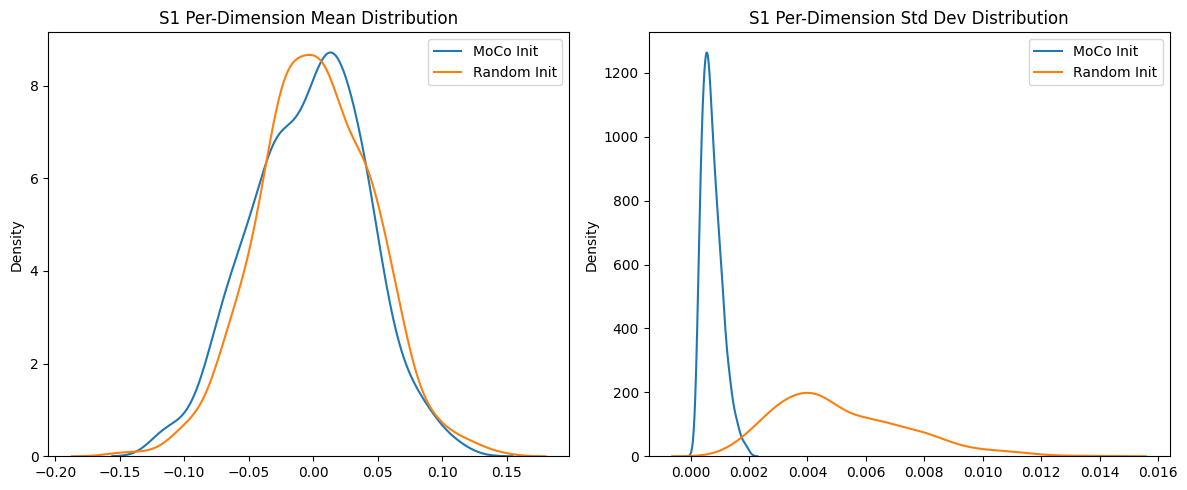

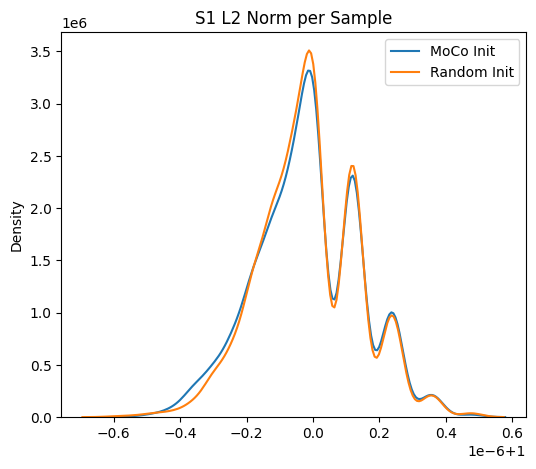

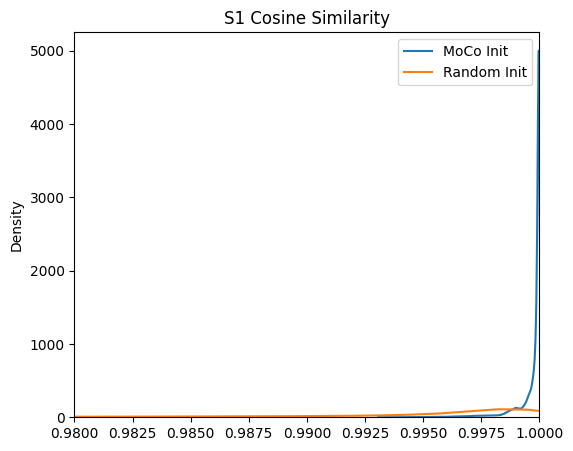

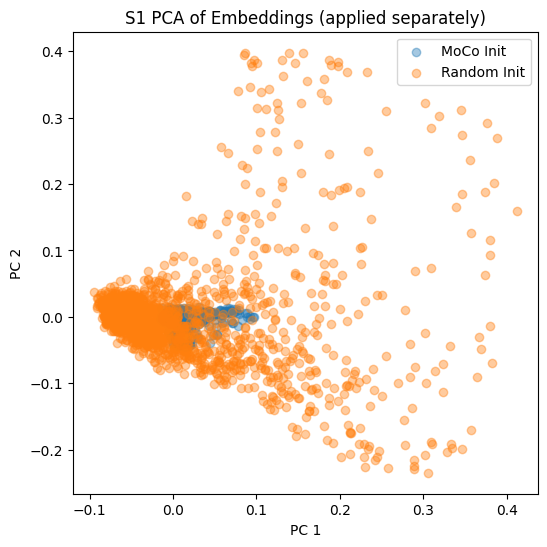

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import torch
import torch.nn.functional as F

df1 = s1_df
df2 = s2_df

# Convert DataFrames to PyTorch tensors
emb1 = torch.tensor(df1.values, dtype=torch.float32)
emb2 = torch.tensor(df2.values, dtype=torch.float32)

# ---- 1. Per-Dimension Statistics ----
mean1 = emb1.mean(dim=0)
mean2 = emb2.mean(dim=0)
std1 = emb1.std(dim=0)
std2 = emb2.std(dim=0)

# ---- 2. Histograms of Mean and Std ----
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(mean1.numpy(), label='MoCo Init')
sns.kdeplot(mean2.numpy(), label='Random Init')
plt.title("S1 Per-Dimension Mean Distribution")
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(std1.numpy(), label='MoCo Init')
sns.kdeplot(std2.numpy(), label='Random Init')
plt.title("S1 Per-Dimension Std Dev Distribution")
plt.legend()
plt.tight_layout()
plt.show()

# ---- 3. L2 Norm Distributions ----
l2_1 = emb1.norm(p=2, dim=1)
l2_2 = emb2.norm(p=2, dim=1)

plt.figure(figsize=(6, 5))
sns.kdeplot(l2_1.numpy(), label='MoCo Init')
sns.kdeplot(l2_2.numpy(), label='Random Init')
plt.title("S1 L2 Norm per Sample")
plt.legend()
plt.show()

# ---- 4. Cosine Similarity Distributions (Upper Triangle Only) ----
def cosine_sim_distribution(emb):
    emb_norm = F.normalize(emb, p=2, dim=1)
    cos_sim = torch.matmul(emb_norm, emb_norm.T)
    N = emb.shape[0]
    i, j = torch.triu_indices(N, N, offset=1)
    return cos_sim[i, j].numpy()

cos_sim1_vals = cosine_sim_distribution(emb1)
cos_sim2_vals = cosine_sim_distribution(emb2)

plt.figure(figsize=(6, 5))
sns.kdeplot(cos_sim1_vals, label='MoCo Init')
sns.kdeplot(cos_sim2_vals, label='Random Init')
plt.xlim([0.98, 1])
plt.title("S1 Cosine Similarity")
plt.legend()
plt.show()

# ---- 5. PCA Visualization ----
def pca_2d(emb):
    pca = PCA(n_components=2)
    return pca.fit_transform(emb.numpy())

pca1 = pca_2d(emb1)
pca2 = pca_2d(emb2)

plt.figure(figsize=(6, 6))
plt.scatter(pca1[:, 0], pca1[:, 1], alpha=0.4, label='MoCo Init')
plt.scatter(pca2[:, 0], pca2[:, 1], alpha=0.4, label='Random Init')
plt.title("S1 PCA of Embeddings (applied separately)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.show()



In [ ]:
#

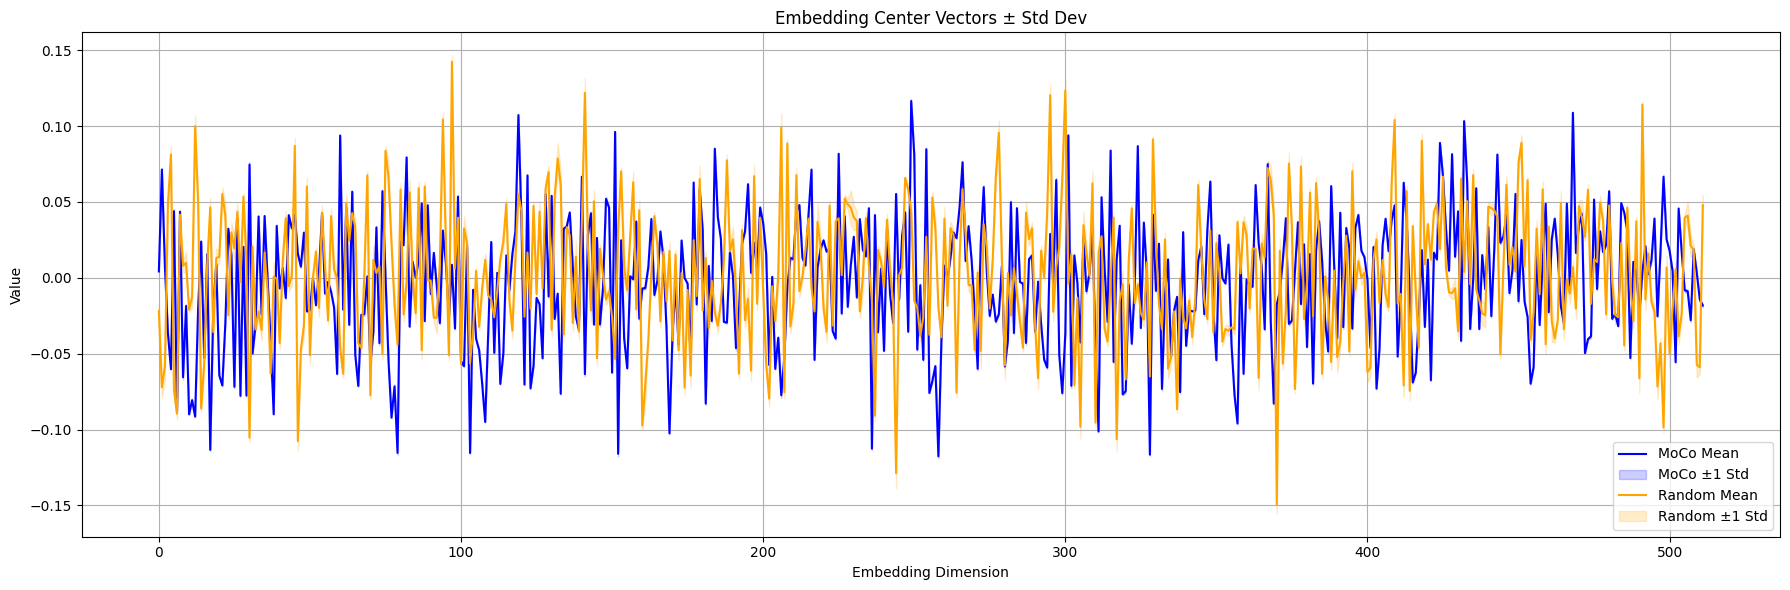

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Assume emb1 and emb2 are (2000, 512) PyTorch tensors
mean1 = emb1.mean(dim=0).numpy()
std1 = emb1.std(dim=0).numpy()

mean2 = emb2.mean(dim=0).numpy()
std2 = emb2.std(dim=0).numpy()

dims = np.arange(512)

plt.figure(figsize=(18, 6))

# MoCo Initialized
plt.plot(dims, mean1, label='MoCo Mean', color='blue')
plt.fill_between(dims, mean1 - std1, mean1 + std1, alpha=0.2, color='blue', label='MoCo ±1 Std')

# Random Initialized
plt.plot(dims, mean2, label='Random Mean', color='orange')
plt.fill_between(dims, mean2 - std2, mean2 + std2, alpha=0.2, color='orange', label='Random ±1 Std')

# plt.xlim(0, 100)

plt.title("Embedding Center Vectors ± Std Dev")
plt.xlabel("Embedding Dimension")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


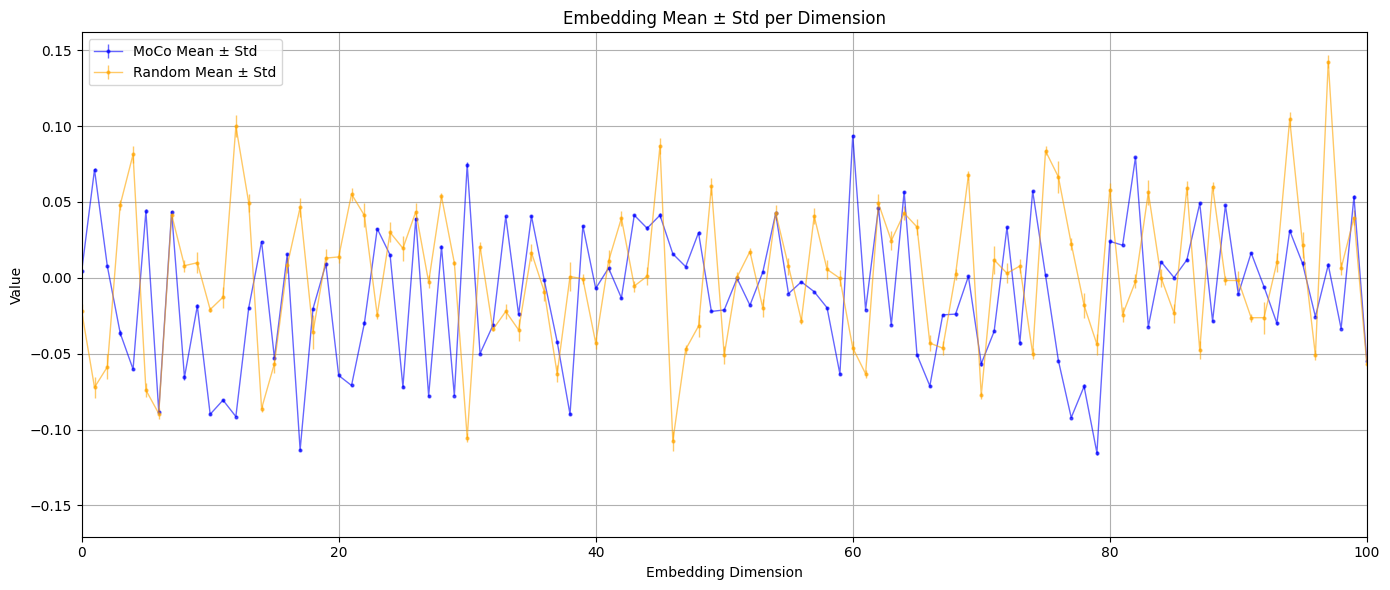

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(512)
plt.figure(figsize=(14, 6))

# MoCo
plt.errorbar(x, mean1, yerr=std1, fmt='-o', markersize=2, linewidth=1, label='MoCo Mean ± Std', color='blue', alpha=0.6)

# Random
plt.errorbar(x, mean2, yerr=std2, fmt='-o', markersize=2, linewidth=1, label='Random Mean ± Std', color='orange', alpha=0.6)
plt.xlim([0, 100])
plt.xlabel('Embedding Dimension')
plt.ylabel('Value')
plt.title('Embedding Mean ± Std per Dimension')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()







In [ ]:
cols = s1_df.columns.tolist()[0:511]

S1-MoCo-Init:              values
count  1.022000e+06
mean  -3.050514e-03
std    4.412472e-02
min   -1.254057e-01
25%   -3.323960e-02
50%    2.808376e-04
75%    2.824509e-02
max    1.237764e-01
S1-Random-Init:              values
count  1.022000e+06
mean   2.056300e-03
std    4.413774e-02
min   -1.758086e-01
25%   -2.674136e-02
50%    1.829750e-03
75%    3.415246e-02
max    1.717000e-01
S2-MoCo-Init:              values
count  1.022000e+06
mean  -4.229008e-04
std    4.404669e-02
min   -1.523411e-01
25%   -3.291067e-02
50%   -4.696997e-04
75%    3.185750e-02
max    1.367745e-01
S2-Random-Init:              values
count  1.022000e+06
mean  -9.966001e-04
std    4.420143e-02
min   -1.410189e-01
25%   -2.994850e-02
50%   -3.187642e-03
75%    2.965810e-02
max    1.513171e-01


,S1-MoCo-Init,S1-Random-Init,S2-MoCo-Init,S2-Random-Init
count,1.022000e+06,1.022000e+06,1.022000e+06,1.022000e+06
mean,-3.050514e-03,2.056300e-03,-4.229008e-04,-9.966001e-04
std,4.412472e-02,4.413774e-02,4.404669e-02,4.420143e-02
min,-1.254057e-01,-1.758086e-01,-1.523411e-01,-1.410189e-01
25%,-3.323960e-02,-2.674136e-02,-3.291067e-02,-2.994850e-02
50%,2.808376e-04,1.829750e-03,-4.696997e-04,-3.187642e-03
75%,2.824509e-02,3.415246e-02,3.185750e-02,2.965810e-02
max,1.237764e-01,1.717000e-01,1.367745e-01,1.513171e-01


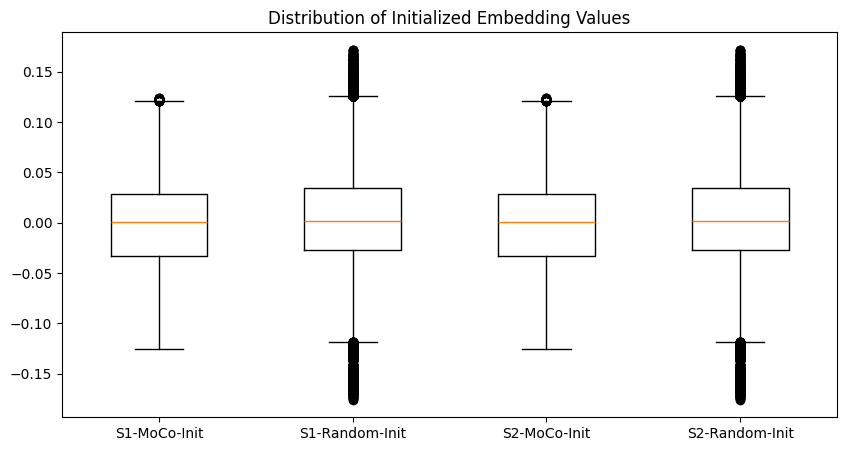

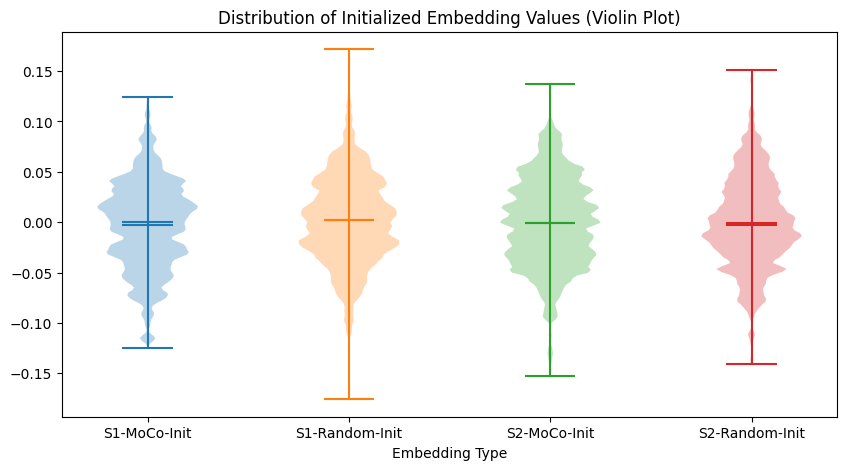

In [ ]:
# model_names = ['MoCoInit', 'RandomInitialization']
s1_df.describe()
# s2_df

# plot the distribution across all values in the dataframe
s1_df_moco = s1_df[cols].values.reshape(-1).astype(float)
plt.figure(figsize=(10, 5))
plt.boxplot(s1_df_moco, positions=[0], widths=0.5, label='S1-MoCo-Init')
s1_df_moco  = pd.DataFrame(s1_df_moco, columns=['values'])
print(f'S1-MoCo-Init: {s1_df_moco.describe()}')


s1_df_random = s1_df2[cols].values.reshape(-1).astype(float)
plt.boxplot(s1_df_random, positions=[1], widths=0.5, label='S1-Random-Init')
s1_df_random = pd.DataFrame(s1_df_random, columns=['values'])
print(f'S1-Random-Init: {s1_df_random.describe()}')

s2_df_moco = s2_df[cols].values.reshape(-1).astype(float)
plt.boxplot(s1_df_moco, positions=[2], widths=0.5, label='S2-MoCo-Init')
s2_df_moco = pd.DataFrame(s2_df_moco, columns=['values'])
print(f'S2-MoCo-Init: {s2_df_moco.describe()}')

s2_df_random = s2_df2[cols].values.reshape(-1).astype(float)
plt.boxplot(s1_df_random, positions=[3], widths=0.5, label='S2-Random-Init')
s2_df_random = pd.DataFrame(s2_df_random, columns=['values'])
print(f'S2-Random-Init: {s2_df_random.describe()}')
plt.xticks([0, 1, 2, 3], ['S1-MoCo-Init', 'S1-Random-Init', 'S2-MoCo-Init', 'S2-Random-Init'])

plt.title('Distribution of Initialized Embedding Values')


#####3
# now do the same with violinplots
plt.figure(figsize=(10, 5))
plt.violinplot(s1_df_moco['values'], positions=[0], widths=0.5, showmeans=True, showmedians=True)
plt.violinplot(s1_df_random['values'], positions=[1], widths=0.5, showmeans=True, showmedians=True)
plt.violinplot(s2_df_moco['values'], positions=[2], widths=0.5, showmeans=True, showmedians=True)
plt.violinplot(s2_df_random['values'], positions=[3], widths=0.5, showmeans=True, showmedians=True)
plt.xticks([0, 1, 2, 3], ['S1-MoCo-Init', 'S1-Random-Init', 'S2-MoCo-Init', 'S2-Random-Init'])
plt.title('Distribution of Initialized Embedding Values (Violin Plot)')
plt.xlabel('Embedding Type')



# put describe in a table
stats_df = pd.DataFrame({
    'S1-MoCo-Init': s1_df_moco['values'].describe(),
    'S1-Random-Init': s1_df_random['values'].describe(),
    'S2-MoCo-Init': s2_df_moco['values'].describe(),
    'S2-Random-Init': s2_df_random['values'].describe()
})
display(stats_df)

In [ ]:
# cosine distance


In [ ]:
s1_df_moco

array([0.0048119560815393925, 0.07233048975467682, 0.00789259746670723,
       ..., -0.01458856463432312, -0.018604906275868416,
       '0135584_season0'], dtype=object)

In [ ]:
# descriptive statistics 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(negative_samples, bins=100, kde=True)
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Distribution of Negative Sample Cosine Similarities")
plt.show()


NameError: name 'negative_samples' is not defined

In [ ]:
# apply PCS

# Plot embedding distances

In [ ]:
# # extract info
# col1 = 's1'
# col2 = 's2'
# coordinates, vh_crs, vv_crs, s1_embeddings, s2_embeddings = extract_sample_info(sampled)
# cosine_similarities = get_cosine_similarity(s1_embeddings, s2_embeddings, col1, col2)
# distances = return_distance_calculation(coordinates, vh_crs, vv_crs)

# # pd dataframe
# df = pd.DataFrame(distances, columns=['s1_sample', 's2_sample', 'distance'])
# df2 = pd.DataFrame(cosine_similarities, columns=['s1_sample', 's2_sample', 'cosine_similarity'])
# df = pd.merge(df, df2, on=['s1_sample', 's2_sample'])


# print(f'Max distance: {df["distance"].max()} | Min distance: {df["distance"].min()}')


# # drop same pairs
# df.drop(index=df.loc[df['s1_sample'] == df['s2_sample']].index, inplace=True)

# # plot distribution of distance
# plt.figure(figsize=(3, 3))
# plt.violinplot(df['distance'])
# plt.title(f'Violinplot: Distribution of distances between {len(sampled)} pairs')
# plt.ylabel('Distance (km)')


# # scatterplot
# plt.figure(figsize=(5, 5))
# plt.scatter(df['distance'], df['cosine_similarity'], s=7)
# plt.xlabel('Distance (km)')
# plt.ylabel('Cosine similarity')
# plt.title(f'{len(sampled)} samples - Cosine Similarity between {col1}-{col2} embedding pairs')
# # plot regression line
# z = np.polyfit(df['distance'], df['cosine_similarity'], 1)
# p = np.poly1d(z)
# plt.plot(df['distance'],p(df['distance']),"r--")
# plt.show()


# plot_coordinates(coordinates, vh_crs, vv_crs)


# Dimensionality reduction

In [ ]:
# s1_df.drop(columns=['sat'], inplace=True)
# s2_df.drop(columns=['sat'], inplace=True)


In [ ]:



# using the selected samples, calculate the cosine similarity between each combination
selected_df1 = s1_df#.iloc[indices]
selected_df2 = s2_df#.iloc[indices]

selected_df1.reset_index(inplace=True, drop=True)
selected_df2.reset_index(inplace=True,  drop=True)


# calculate  similarity between each sample
similarities = []
for i in range(len(selected_df1)):
    for j in range(i, len(selected_df2)):
        cos_sim = torch.nn.functional.cosine_similarity(torch.tensor(selected_df1.iloc[i].values), torch.tensor(selected_df2.iloc[j].values), dim=0)
        similarities.append((i, j, cos_sim.item()))

similarities_df = pd.DataFrame(similarities, columns=['s1_sample', 's2_sample', 'cosine_similarity'])
merged_df = similarities_df


# # calculate euclidean
# euclidean_distances = []
# for i in range(len(selected_df1)):
#     for j in range(i, len(selected_df2)):
#         dist = np.linalg.norm(selected_df1.iloc[i] - selected_df2.iloc[j])
#         euclidean_distances.append((i, j, dist))


# # convert to dataframe
# euclidean_df = pd.DataFrame(euclidean_distances, columns=['s1_sample', 's2_sample', 'euclidean_distance'])
# euclidean_df.head()

# # merge the two dataframes
# merged_df = pd.merge(similarities_df, euclidean_df, on=['s1_sample', 's2_sample'])
# merged_df.head()


# # plot
# plt.figure(figsize=(5, 5))
# plt.scatter(pairs['euclidean_distance'], pairs['cosine_similarity'], s=7)
# plt.xlabel('Euclidean distance')
# plt.ylabel('Cosine similarity')
# plt.title(f'{len(sampled)} samples - Cosine Similarity between {col1}-{col2} embedding pairs')
# # plot regression line
# z = np.polyfit(pairs['euclidean_distance'], pairs['cosine_similarity'], 1)
# p = np.poly1d(z)
# plt.plot(pairs['euclidean_distance'], p(pairs['euclidean_distance']), "r--")
# plt.show()



Number of pairs: 1000


In [ ]:
pairs = merged_df['s1_sample'] == merged_df['s2_sample']
pairs = merged_df[pairs]
print(f'Number of pairs: {len(pairs)}')


merged_df['paired'] = merged_df['s1_sample'] == merged_df['s2_sample']

random_indices = np.random.choice(range(len(merged_df.loc[~merged_df.paired])), size=1000, replace=False)
negative_samples = merged_df.loc[~merged_df.paired].iloc[random_indices]

# COSINE
plt.figure(figsize=(5, 5))
plt.boxplot(merged_df.loc[merged_df.paired, 'cosine_similarity'], positions=[0], widths=0.5)
plt.boxplot(negative_samples['cosine_similarity'], positions=[1], widths=0.5)
plt.xticks([0, 1], ['positive', 'negative'])
plt.title(f'Distribution of cosine_similarity between {len(sampled)} pairs')
plt.ylabel('Cosine Similarity')
plt.show()

,s1_sample,s2_sample,cosine_similarity,paired
1,0,1,-0.043723,False
2,0,2,-0.010096,False
3,0,3,0.032054,False
4,0,4,-0.012656,False
5,0,5,-0.001464,False
...,...,...,...,...
500492,996,998,-0.011844,False
500493,996,999,-0.021699,False
500495,997,998,0.022048,False
500496,997,999,0.029311,False


In [ ]:
merged_df.loc[merged_df.paired, 'euclidean_distance'].describe()

count    200.000000
mean       1.413259
std        0.018988
min        1.374028
25%        1.397454
50%        1.412424
75%        1.428172
max        1.447534
Name: euclidean_distance, dtype: float64

In [ ]:
merged_df.loc[~merged_df.paired, 'euclidean_distance'].describe()

count    19900.000000
mean         1.411245
std          0.014826
min          1.369575
25%          1.400376
50%          1.410855
75%          1.422131
max          1.457837
Name: euclidean_distance, dtype: float64

In [ ]:
longs = [coordinates[i][0] for i in indices]
lats = [coordinates[i][1] for i in indices]

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from shapely.geometry import Point


# Extract the selected embeddings and locations
c = [coordinates[i] for i in indices]

# Create GeoDataFrames
gdf_type1 = gpd.GeoDataFrame(selected_df_type1, geometry=gpd.points_from_xy(longs, lats))
gdf_type2 = gpd.GeoDataFrame(selected_df_type2,  geometry=gpd.points_from_xy(longs, lats))

# # Load a world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# # Plot the world map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
world.boundary.plot(ax=ax)

# # Define a colormap
# colors = plt.cm.get_cmap('tab10', num_locations)

# # Plot each pair of embeddings with a unique color
# for i in range(num_locations):
#     color = colors(i)
#     ax.scatter(gdf_type1.geometry.x.iloc[i], gdf_type1.geometry.y.iloc[i], color=color, label=f'Location {selected_df_type1.id.iloc[i]} Type 1', s=100)
#     ax.scatter(gdf_type2.geometry.x.iloc[i], gdf_type2.geometry.y.iloc[i], color=color, marker='x', label=f'Location {selected_df_type2.id.iloc[i]} Type 2', s=100)

# # Add custom legend
# from matplotlib.lines import Line2D

# legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Type 1'),
#                    Line2D([0], [0], marker='x', color='w', markerfacecolor='black', markersize=10, label='Type 2')]

# # Add the custom legend
# ax.legend(handles=legend_elements, loc='best')
# plt.xlabel('Longitude')
# plt.ylabel('Latitude')
# plt.title('Geographical Embeddings on Map')
# plt.grid(True)
# plt.show()


NameError: name 'coordinates' is not defined

In [ ]:
# import random
# n = 5  # Number of points to annotate
# indices = random.sample(range(len(s1_df)), n)
# sampled_x = s1_pca[:, 0][indices]
# sampled_y = s1_pca[:, 1][indices]

# s1_filepaths = [sampled[i]['s1_filepath'] for i in indices]
# s2_filepaths = [fp.replace('s1', 's2c') for fp in filepaths]
# season_nums = [int(i.split('season')[-1]) for i in s1_df[indices].index]

# # # load images
# s1_imgs = load_s1_images(s1_filepaths, season_nums)
# s2_imgs = load_s2_images(s2_filepaths, season_nums)

# for i, (img, x_i, y_i) in enumerate(zip(images, sampled_x, sampled_y)):
#     imagebox = OffsetImage(img, zoom=0.1)
#     ab = AnnotationBbox(imagebox, (x_i, y_i), frameon=False)
#     plt.gca().add_artist(ab)
#     plt.plot([x_i, x_i], [y_i, y_i + 0.05], 'k-')  # Line from point to image

# plt.show()

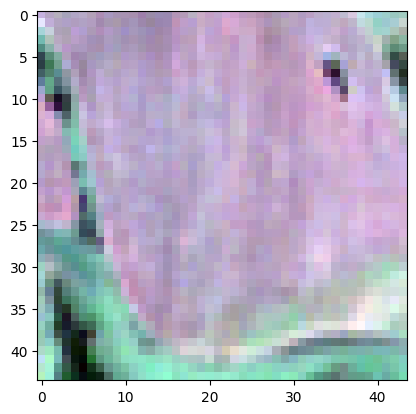

In [ ]:
s2_imgs[0]

# plot img
plt.imshow(s2_imgs[2])

In [ ]:
import rasterio

S1_MEAN = [-12.54847273, -20.19237134]
S1_STD = [5.25697717, 5.91150917]

S2A_MEAN = [752.40087073, 884.29673756, 1144.16202635, 1297.47289228, 1624.90992062, 2194.6423161, 2422.21248945, 2517.76053101, 2581.64687018, 2645.51888987, 2368.51236873, 1805.06846033]
S2A_STD = [1108.02887453, 1155.15170768, 1183.6292542, 1368.11351514, 1370.265037, 1355.55390699, 1416.51487101, 1474.78900051, 1439.3086061, 1582.28010962, 1455.52084939, 1343.48379601]

S2C_MEAN = [1605.57504906, 1390.78157673, 1314.8729939, 1363.52445545, 1549.44374991, 2091.74883118, 2371.7172463, 2299.90463006, 2560.29504086, 830.06605044, 22.10351321, 2177.07172323, 1524.06546312]
S2C_STD = [786.78685367, 850.34818441, 875.06484736, 1138.84957046, 1122.17775652, 1161.59187054, 1274.39184232, 1248.42891965, 1345.52684884, 577.31607053, 51.15431158, 1336.09932639, 1136.53823676]


def read_raster_image(image_path):
    with rasterio.open(image_path) as src:
        return src.read(1), src.profile

def normalize(img, mean, std):
        min_value = mean - 2 * std
        max_value = mean + 2 * std
        img = (img - min_value) / (max_value - min_value) * 255.0
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img
            
def load_s1(path_to_sample, season_num):
    # TODO: double check season loading logic
    season_name = os.listdir(path_to_sample)[season_num]
    path_to_season = os.path.join(path_to_sample, season_name)


    vh_path = os.path.join(path_to_season, 'VH.tif')
    vv_path = os.path.join(path_to_season, 'VV.tif')
    vh_image, _ = read_raster_image(vh_path)
    vv_image, _ = read_raster_image(vv_path)

    # Normalize the VH and VV bands
    vv_image = normalize(vv_image, S1_MEAN[0], S1_STD[0])
    vh_image = normalize(vh_image, S1_MEAN[1], S1_STD[1])

            
    # Create an RGB composite using VH, VV, and their average
    s1_composite_image = np.stack((vh_image, vv_image, np.zeros_like(vv_image)), axis=-1)

    # convert to ints
    s1_composite_image = s1_composite_image.astype(np.uint8)
    return s1_composite_image

def load_s1_images(filepaths, season_nums):
    images = []
    for path, season_num in zip(filepaths, season_nums):
        img = load_s1(path, season_num)
        images.append(img)
    return images


def load_s2(path, season_num):
    season_name = os.listdir(path)[season_num]
    path_to_season = os.path.join(path, season_name)

    band_paths = [os.path.join(path_to_season, f'B{band}.tif') for band in range(1, 13)]
 
    # Ensure all bands have the same shape
    band_images = [read_raster_image(band_path)[0] for band_path in band_paths]
    shapes = [band_image.shape for band_image in band_images]
    min_shape = min(shapes, key=lambda x: x[0] * x[1])
    band_images = [band_image[:min_shape[0], :min_shape[1]] for band_image in band_images]

    # select bands 4, 3, 2
    # band_images = [band_images[i] for i in [2, 3, 4]]
    # Define the RGB bands for Sentinel-2
    B02 = band_images[1]  # Blue
    B03 = band_images[2]  # Green
    B04 = band_images[3]  # Red

    def normalize(array):
        array_min, array_max = array.min(), array.max()
        return (array - array_min) / (array_max - array_min)

    B02_normalized = normalize(B02)
    B03_normalized = normalize(B03)
    B04_normalized = normalize(B04)

    
    # Normalize the bands
    # band_images = [self.normalize_image(band_image) for band_image in band_images]
    # band_images = [normalize(img, mean, std) for img, mean, std in zip(band_images, S2C_MEAN, S2C_STD)]
    
    # s2_composite_image = np.stack(band_images, axis=-1)
    rgb_image = np.dstack((B04_normalized, B03_normalized, B02_normalized))

    return rgb_image

def load_s2_images(filepaths, season_nums):
    # load images
    s2_imgs = []
    for filepath, season_num in zip(filepaths, season_nums):
        img = load_s2(filepath, season_num)
        s2_imgs.append(img)

    return s2_imgs
